# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


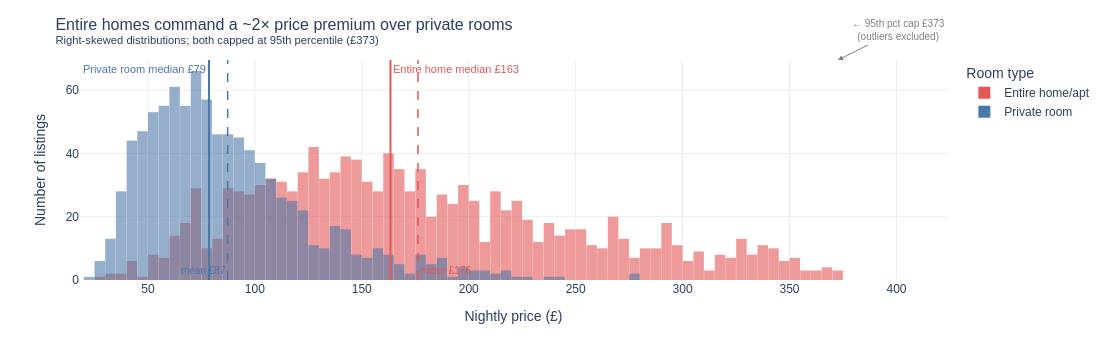

In [3]:
# ── Filter to the two room types of interest ────────────────────────────────
room_types = ['Entire home/apt', 'Private room']
df_plot = df_cap[df_cap['room_type'].isin(room_types)].copy()

# ── Compute per-group medians & means ───────────────────────────────────────
stats = (
    df_plot
    .groupby('room_type')['price']
    .agg(median='median', mean='mean')
    .to_dict('index')
)

# Colour palette — colour encodes room type, not decoration
COLOURS = {
    'Entire home/apt': '#E45756',   # warm red  → higher-price group
    'Private room':    '#4C78A8',   # cool blue → lower-price group
}

# ── Build the overlaid histogram ─────────────────────────────────────────────
fig = px.histogram(
    df_plot,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=80,
    color_discrete_map=COLOURS,
    labels={'price': 'Nightly price (£)', 'room_type': 'Room type'},
)

# ── Add median vertical lines (one per room type, colour-matched) ────────────
for room, colour in COLOURS.items():
    med = stats[room]['median']
    mn  = stats[room]['mean']

    # Median line
    fig.add_vline(
        x=med,
        line_width=2,
        line_dash='solid',
        line_color=colour,
        annotation_text=f"{room.split('/')[0].strip()} median £{med:.0f}",
        annotation_position='top right' if room == 'Entire home/apt' else 'top left',
        annotation_font_color=colour,
        annotation_font_size=11,
    )

    # Mean line (dashed, same colour family)
    fig.add_vline(
        x=mn,
        line_width=1.5,
        line_dash='dash',
        line_color=colour,
        annotation_text=f"mean £{mn:.0f}",
        annotation_position='bottom right' if room == 'Entire home/apt' else 'bottom left',
        annotation_font_color=colour,
        annotation_font_size=10,
    )

# ── 95th-percentile cap annotation ──────────────────────────────────────────
fig.add_annotation(
    x=p95,
    y=1,
    yref='paper',
    text=f"← 95th pct cap £{p95:.0f}<br>(outliers excluded)",
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-30,
    font=dict(size=10, color='grey'),
    arrowcolor='grey',
)

# ── Layout & insight title ───────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text=(
            "Entire homes command a ~2× price premium over private rooms<br>"
            "<sup>Right-skewed distributions; both capped at 95th percentile "
            f"(£{p95:.0f})</sup>"
        ),
        font_size=16,
    ),
    xaxis_title="Nightly price (£)",
    yaxis_title="Number of listings",
    legend_title_text="Room type",
    bargap=0.02,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee'),
    yaxis=dict(showgrid=True, gridcolor='#eeeeee'),
)

fig.show()



## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

Active listings: 2495 / 2500 (5 zero-review listings removed)
Two busiest boroughs: Tower Hamlets & Hackney


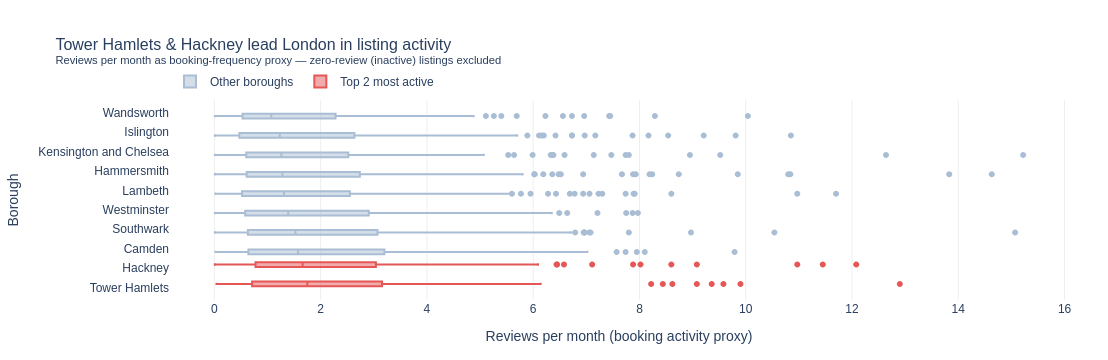

In [4]:
# Task 2
df_active = df[df['reviews_per_month'] > 0].copy()
print(f"Active listings: {len(df_active)} / {len(df)} "
      f"({len(df) - len(df_active)} zero-review listings removed)")

# ── Sort boroughs by median reviews per month (ascending so top = most active)
median_order = (
    df_active
    .groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=True)   # px plots categories bottom→top
)
sorted_boroughs = median_order.index.tolist()
top2 = median_order.iloc[-2:].index.tolist()   # two highest medians

print(f"Two busiest boroughs: {top2[1]} & {top2[0]}")

# ── Colour encodes activity tier: highlight top 2, mute the rest ─────────────
HIGHLIGHT = '#E45756'   # warm red — most active
BASELINE  = '#A9BDD4'   # desaturated blue — all others

df_active['colour_group'] = df_active['neighbourhood'].apply(
    lambda b: 'Top 2 most active' if b in top2 else 'Other boroughs'
)

colour_map = {
    'Top 2 most active': HIGHLIGHT,
    'Other boroughs':    BASELINE,
}

# ── Build horizontal box plot ─────────────────────────────────────────────────
fig = px.box(
    df_active,
    x='reviews_per_month',
    y='neighbourhood',
    color='colour_group',
    color_discrete_map=colour_map,
    category_orders={'neighbourhood': sorted_boroughs},
    points='outliers',
    labels={
        'reviews_per_month': 'Reviews per month (booking activity proxy)',
        'neighbourhood':     'Borough',
        'colour_group':      '',
    },
    title=(
        f"{top2[1]} & {top2[0]} lead London in listing activity<br>"
        "<sup>Reviews per month as booking-frequency proxy — "
        "zero-review (inactive) listings excluded</sup>"
    ),
)

# ── Layout polish ─────────────────────────────────────────────────────────────
fig.update_layout(
    title_font_size=16,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#eeeeee', zeroline=False),
    yaxis=dict(showgrid=False),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    margin=dict(l=140, r=40, t=100, b=60),
)

fig.show()

